In [17]:
suppressMessages({library("rwwa"); library("shape")})

prep_window <- function (rc = c(1, 1), w = 7, h = 7, res = 120, ...) {
    options(repr.plot.width = rc[2] * w, repr.plot.height = rc[1] * h, repr.plot.res = res)
    par(mfrow = rc, ...)
}

res <- 480; fh <- res; fw <- res * 10/7

main <- "Hottest 14-day period over Fennoscandia"

# Regression model

In [2]:
df <- merge(read.table("../ts/gmst.txt", comment.char = "#", col.names = c("year", "gmst")), 
            load_ts("../ts/fs-heatwave_tx14x_era5.dat", col.names = c("year", "x")))

df$gmst <- df$gmst - df$gmst[df$year == 2025]

cov_f <- data.frame(gmst = 0)
cov_cf <- rbind("pi" = data.frame(gmst = -1.3),
                "2018" = data.frame(gmst = df$gmst[df$year == 2018]))

In [3]:
mdl <- fit_ns("gev", "shift", data = df, covnm = "gmst", varnm = "x", ev_year = 2025)

In [4]:
boot_res <- boot_ci(mdl, cov_f, cov_cf, nsamp = 1000)
write.csv(boot_res, "res-era5.csv")

In [5]:
boot_res

,est,2.5%,97.5%
mu0,20.69880566,19.51738039,21.81212819
sigma0,1.57516543,1.20085019,1.86506166
alpha_gmst,2.01730489,0.69577540,3.22959999
shape,-0.24933347,-0.44065295,-0.04724892
disp,0.07609934,0.05848031,0.08976119
event_magnitude,24.86554337,24.86554337,24.86554337
return_period,75.80414936,18.55682303,Inf
PR_pi,Inf,3.86081317,Inf
dI_abs_pi,2.62249636,1.01150765,4.20502299
dI_rel_pi,11.79018487,4.24040467,20.35293841


In [10]:
prob_ratio(mdl, ev = df$x[df$year == 2018], cov_f = cov_f, cov_cf = cov_cf["2018",,drop = F])

[1] 1.873426

In [18]:
png(paste0("fig/trend-with-2018.png"), h = fh*0.75, w = fw); {
    plot(df$year+0.5, df$x, type = "S", lwd = 2, ylab = "Temperature (°C)", xlab = "Year", main = main, ylim = ylim, cex.lab = 1.2)
    points(df[df$year %in% c(2018, 2025),c("year", "x")], pch = 0, lwd = 2, col = "magenta")
}; dev.off()

agg_record_1863069132 
                    2

In [19]:
png(paste0("fig/returnlevels_era5.png"), h = fh, w = fh); {
    par(lwd = 2, mar = c(5.4,4.1,1,1))
    plot_returnlevels(mdl, cov_f, cov_cf["pi",,drop = F], nsamp = 500, ylab = "Temperature (°C)", legend_pos = "bottomright")
}; dev.off()

agg_record_115281583 
                   2

In [20]:
png(paste0("fig/returnlevels-2018_era5.png"), h = fh, w = fh); {
    par(lwd = 2, mar = c(5.4,4.1,1,1))
    plot_returnlevels(mdl, ev = df$x[df$year == 2018], cov_f, cov_cf["2018",,drop = F], nsamp = 500, ylab = "Temperature (°C)", legend_pos = "bottomright")
}; dev.off()

agg_record_901430611 
                   2

In [21]:
png("fig/trendplot_change-since-2018.png", h = fh, w = fh * 2); {

    par(lwd = 2, mar = c(5.4,4.1,1,1))
    
    plot(df$gmst, df$x, type = "p", pch = 20, ylim = ylim, xlab = "GMST anomaly wrt 2025", ylab = "Temperature (°C)", main = "")
    points(df[df$year == 2025,c("gmst", "x")], pch = 0, lwd = 2, col = "magenta")
    points(df[df$year == 2018,c("gmst", "x")], pch = 0, lwd = 2, col = "magenta")

    lines(df$gmst[order(df$gmst)], ns_pars(mdl)$loc[order(df$gmst)], lwd = 2)

    y_2018 <- ns_pars(mdl, fixed_cov = data.frame("gmst" = df$gmst[df$year == 2018]))$loc
    y_2025 <- ns_pars(mdl, fixed_cov = data.frame("gmst" = 0))$loc
    dI_2018 <- round(int_change(mdl, 10, cov_f, cov_cf["2018",,drop = F]),1)

    # Arrows(-0.2,y_2018,0,y_2018, col = "orange", lw = 2, arr.adj = 1, arr.type = "none", segments = T)
    lines(c(-0.2,0),rep(y_2018,2), col = "orange", lw = 2)
    text(-0.1, y_2018-0.35, "+ 0.2°C",  col = "orange")
    
    lines(c(0,0),c(y_2018,y_2025), col = "orange", lw = 2)
    text(0,y_2025, paste0("+ ",dI_2018,"°C"),  col = "orange", pos = 3)
    
}; dev.off()

agg_record_901430611 
                   2

# Trend plots

In [25]:
# set some common parameters
ylim <- range(pretty(df$x))

y_pi <- ns_pars(mdl, fixed_cov = data.frame("gmst" = -1.3))$loc
y_2025 <- ns_pars(mdl, fixed_cov = data.frame("gmst" = 0))$loc

loc_range <- ns_pars(mdl)$loc[df$gmst == 0] + boot_res["dI_abs_pi",c(2,3)] - boot_res["dI_abs_pi",c(1)]

dI <- round(boot_res["dI_abs_pi", "est"],1)
erl_10 <- eff_return_level(mdl, 10)[order(df$gmst)]
rp <- round(boot_res["return_period","est"])

In [27]:
prep_window(w = 10)

png(paste0("fig/trend-1_timeseries.png"), h = fh, w = fw); {
    plot(df$year, df$x, type = "S", lwd = 2, ylab = "Temperature (°C)", xlab = "Year", main = main, ylim = ylim, cex.lab = 1.2)
    points(df[df$gmst == 0,c("year", "x")], pch = 0, lwd = 2, col = "magenta")
}; dev.off()

agg_record_90062117 
                  2

In [28]:
png("fig/trend-2_vs-gmst.png", h = fh, w = fw); {
    
    plot(df$gmst, df$x, type = "p", pch = 20, ylim = ylim, xlab = "GMST anomaly wrt 2025", ylab = "Temperature (°C)", main = main)
    points(df[df$gmst == 0,c("gmst", "x")], pch = 0, lwd = 2, col = "magenta")

    # lines(df$gmst[order(df$gmst)], ns_pars(mdl)$loc[order(df$gmst)], lwd = 2)
    # lines(df$gmst[order(df$gmst)], fitted(loess(x ~ gmst, df))[order(df$gmst)], col = "forestgreen", lwd = 3, lty = "22")
    # Arrows(-1.3,y_pi,0,y_pi, col = "orange", lw = 2, arr.adj = 1, arr.type = "curved")
    # text(-0.5, y_pi-0.35, "GMST has increased by 1.3°C",  col = "orange")
    
    # Arrows(0,y_pi,0,y_2025, col = "orange", lw = 2, arr.adj = 1, arr.type = "curved")
    # text(-0.01,(y_2025+y_pi)/2-0.1, paste0(dI,"ºC increase\nin local temp"),  col = "orange", adj = 1)
    
    # Arrows(0.02, loc_range[1], 0.02, loc_range[2], lwd = 3, arr.type = "T", code = 3)

    # lines(df$gmst[order(df$gmst)], erl_10, col = "darkred", lw = 2, lty = 2)
    # text(-0.4, erl_10[length(erl_10)]-0.25, "1-in-10-year\nevent     ", pos = 2, adj = 0.5, col = "darkred", font = 2)

    # text(0,df$x[df$year == 2025], paste0("1-in-",rp,"-year\nevent     "), pos = 2, adj = 0.5, col = "magenta", font = 2)
}; dev.off()

agg_record_1996882048 
                    2

In [29]:
png("fig/trend-3_linear-model.png", h = fh, w = fw); {
    
    plot(df$gmst, df$x, type = "p", pch = 20, ylim = ylim, xlab = "GMST anomaly wrt 2025", ylab = "Temperature (°C)", main = main)
    points(df[df$gmst == 0,c("gmst", "x")], pch = 0, lwd = 2, col = "magenta")

    lines(df$gmst[order(df$gmst)], ns_pars(mdl)$loc[order(df$gmst)], lwd = 2)
    # lines(df$gmst[order(df$gmst)], fitted(loess(x ~ gmst, df))[order(df$gmst)], col = "forestgreen", lwd = 3, lty = "22")
    
    # Arrows(-1.3,y_pi,0,y_pi, col = "orange", lw = 2, arr.adj = 1, arr.type = "curved")
    # text(-0.5, y_pi-0.35, "GMST has increased by 1.3°C",  col = "orange")
    
    # Arrows(0,y_pi,0,y_2025, col = "orange", lw = 2, arr.adj = 1, arr.type = "curved")
    # text(-0.01,(y_2025+y_pi)/2-0.1, paste0(dI,"ºC increase\nin local temp"),  col = "orange", adj = 1)
    
    # Arrows(0.02, loc_range[1], 0.02, loc_range[2], lwd = 3, arr.type = "T", code = 3)

    # lines(df$gmst[order(df$gmst)], erl_10, col = "darkred", lw = 2, lty = 2)
    # text(-0.4, erl_10[length(erl_10)]-0.25, "1-in-10-year\nevent     ", pos = 2, adj = 0.5, col = "darkred", font = 2)

    # text(0,df$x[df$year == 2025], paste0("1-in-",rp,"-year\nevent     "), pos = 2, adj = 0.5, col = "magenta", font = 2)
}; dev.off()

agg_record_1360922036 
                    2

In [30]:
png("fig/trend-4_loess-smoother.png", h = fh, w = fw); {
    
    plot(df$gmst, df$x, type = "p", pch = 20, ylim = ylim, xlab = "GMST anomaly wrt 2025", ylab = "Temperature (°C)", main = main)
    points(df[df$gmst == 0,c("gmst", "x")], pch = 0, lwd = 2, col = "magenta")

    lines(df$gmst[order(df$gmst)], ns_pars(mdl)$loc[order(df$gmst)], lwd = 2)
    # lines(df$gmst[order(df$gmst)], fitted(loess(x ~ gmst, df))[order(df$gmst)], col = "forestgreen", lwd = 3, lty = "22")
    
    # Arrows(-1.3,y_pi,0,y_pi, col = "orange", lw = 2, arr.adj = 1, arr.type = "curved")
    # text(-0.5, y_pi-0.35, "GMST has increased by 1.3°C",  col = "orange")
    
    # Arrows(0,y_pi,0,y_2025, col = "orange", lw = 2, arr.adj = 1, arr.type = "curved")
    # text(-0.01,(y_2025+y_pi)/2-0.1, paste0(dI,"ºC increase\nin local temp"),  col = "orange", adj = 1)
    
    # Arrows(0.02, loc_range[1], 0.02, loc_range[2], lwd = 3, arr.type = "T", code = 3)

    # lines(df$gmst[order(df$gmst)], erl_10, col = "darkred", lw = 2, lty = 2)
    # text(-0.4, erl_10[length(erl_10)]-0.25, "1-in-10-year\nevent     ", pos = 2, adj = 0.5, col = "darkred", font = 2)

    # text(0,df$x[df$year == 2025], paste0("1-in-",rp,"-year\nevent     "), pos = 2, adj = 0.5, col = "magenta", font = 2)
}; dev.off()

agg_record_643773855 
                   2

In [31]:
png("fig/trend-5_gmst-change.png", h = fh, w = fw); {
    
    plot(df$gmst, df$x, type = "p", pch = 20, ylim = ylim, xlab = "GMST anomaly wrt 2025", ylab = "Temperature (°C)", main = main)
    points(df[df$gmst == 0,c("gmst", "x")], pch = 0, lwd = 2, col = "magenta")

    lines(df$gmst[order(df$gmst)], ns_pars(mdl)$loc[order(df$gmst)], lwd = 2)
    # lines(df$gmst[order(df$gmst)], fitted(loess(x ~ gmst, df))[order(df$gmst)], col = "forestgreen", lwd = 3, lty = "22")
    
    Arrows(-1.3,y_pi,0,y_pi, col = "orange", lw = 2, arr.adj = 1, arr.type = "curved")
    text(-0.5, y_pi-0.35, "GMST has increased by 1.3°C",  col = "orange")
    
    # Arrows(0,y_pi,0,y_2025, col = "orange", lw = 2, arr.adj = 1, arr.type = "curved")
    # text(-0.01,(y_2025+y_pi)/2-0.1, paste0(dI,"ºC increase\nin local temp"),  col = "orange", adj = 1)
    
    # Arrows(0.02, loc_range[1], 0.02, loc_range[2], lwd = 3, arr.type = "T", code = 3)

    # lines(df$gmst[order(df$gmst)], erl_10, col = "darkred", lw = 2, lty = 2)
    # text(-0.4, erl_10[length(erl_10)]-0.25, "1-in-10-year\nevent     ", pos = 2, adj = 0.5, col = "darkred", font = 2)

    # text(0,df$x[df$year == 2025], paste0("1-in-",rp,"-year\nevent     "), pos = 2, adj = 0.5, col = "magenta", font = 2)
}; dev.off()

agg_record_2111337266 
                    2

In [32]:
png("fig/trend-6_local-change.png", h = fh, w = fw); {
    
    plot(df$gmst, df$x, type = "p", pch = 20, ylim = ylim, xlab = "GMST anomaly wrt 2025", ylab = "Temperature (°C)", main = main)
    points(df[df$gmst == 0,c("gmst", "x")], pch = 0, lwd = 2, col = "magenta")

    lines(df$gmst[order(df$gmst)], ns_pars(mdl)$loc[order(df$gmst)], lwd = 2)
    # lines(df$gmst[order(df$gmst)], fitted(loess(x ~ gmst, df))[order(df$gmst)], col = "forestgreen", lwd = 3, lty = "22")
    
    Arrows(-1.3,y_pi,0,y_pi, col = "orange", lw = 2, arr.adj = 1, arr.type = "curved")
    text(-0.5, y_pi-0.35, "GMST has increased by 1.3°C",  col = "orange")
    
    Arrows(0,y_pi,0,y_2025, col = "orange", lw = 2, arr.adj = 1, arr.type = "curved")
    text(-0.01,(y_2025+y_pi)/2-0.1, paste0(dI,"ºC increase\nin local temp"),  col = "orange", adj = 1)
    
    # Arrows(0.02, loc_range[1], 0.02, loc_range[2], lwd = 3, arr.type = "T", code = 3)

    # lines(df$gmst[order(df$gmst)], erl_10, col = "darkred", lw = 2, lty = 2)
    # text(-0.4, erl_10[length(erl_10)]-0.25, "1-in-10-year\nevent     ", pos = 2, adj = 0.5, col = "darkred", font = 2)

    # text(0,df$x[df$year == 2025], paste0("1-in-",rp,"-year\nevent     "), pos = 2, adj = 0.5, col = "magenta", font = 2)
}; dev.off()

agg_record_1805564403 
                    2

In [33]:
png("fig/trend-7_local-change-uncertainty.png", h = fh, w = fw); {
    
    plot(df$gmst, df$x, type = "p", pch = 20, ylim = ylim, xlab = "GMST anomaly wrt 2025", ylab = "Temperature (°C)", main = main)
    points(df[df$gmst == 0,c("gmst", "x")], pch = 0, lwd = 2, col = "magenta")

    lines(df$gmst[order(df$gmst)], ns_pars(mdl)$loc[order(df$gmst)], lwd = 2)
    # lines(df$gmst[order(df$gmst)], fitted(loess(x ~ gmst, df))[order(df$gmst)], col = "forestgreen", lwd = 3, lty = "22")
    
    Arrows(-1.3,y_pi,0,y_pi, col = "orange", lw = 2, arr.adj = 1, arr.type = "curved")
    text(-0.5, y_pi-0.35, "GMST has increased by 1.3°C",  col = "orange")
    
    Arrows(0,y_pi,0,y_2025, col = "orange", lw = 2, arr.adj = 1, arr.type = "curved")
    text(-0.01,(y_2025+y_pi)/2-0.1, paste0(dI,"ºC increase\nin local temp"),  col = "orange", adj = 1)
    
    Arrows(0.02, loc_range[1], 0.02, loc_range[2], lwd = 3, arr.type = "T", code = 3)

    # lines(df$gmst[order(df$gmst)], erl_10, col = "darkred", lw = 2, lty = 2)
    # text(-0.4, erl_10[length(erl_10)]-0.25, "1-in-10-year\nevent     ", pos = 2, adj = 0.5, col = "darkred", font = 2)

    # text(0,df$x[df$year == 2025], paste0("1-in-",rp,"-year\nevent     "), pos = 2, adj = 0.5, col = "magenta", font = 2)
}; dev.off()

NULL

agg_record_933410918 
                   2

In [34]:
png("fig/trend-8_return-level.png", h = fh, w = fw); {
    
    plot(df$gmst, df$x, type = "p", pch = 20, ylim = ylim, xlab = "GMST anomaly wrt 2025", ylab = "Temperature (°C)", main = main)
    points(df[df$gmst == 0,c("gmst", "x")], pch = 0, lwd = 2, col = "magenta")

    lines(df$gmst[order(df$gmst)], ns_pars(mdl)$loc[order(df$gmst)], lwd = 2)
    # lines(df$gmst[order(df$gmst)], fitted(loess(x ~ gmst, df))[order(df$gmst)], col = "forestgreen", lwd = 3, lty = "22")
    
    Arrows(-1.3,y_pi,0,y_pi, col = "orange", lw = 2, arr.adj = 1, arr.type = "curved")
    text(-0.5, y_pi-0.35, "GMST has increased by 1.3°C",  col = "orange")
    
    Arrows(0,y_pi,0,y_2025, col = "orange", lw = 2, arr.adj = 1, arr.type = "curved")
    text(-0.01,(y_2025+y_pi)/2-0.1, paste0(dI,"ºC increase\nin local temp"),  col = "orange", adj = 1)
    
    Arrows(0.02, loc_range[1], 0.02, loc_range[2], lwd = 3, arr.type = "T", code = 3)

    lines(df$gmst[order(df$gmst)], erl_10, col = "darkred", lw = 2, lty = 2)
    text(-0.4, erl_10[length(erl_10)]-0.25, "1-in-10-year\nevent     ", pos = 2, adj = 0.5, col = "darkred", font = 2)

    # text(0,df$x[df$year == 2025], paste0("1-in-",rp,"-year\nevent     "), pos = 2, adj = 0.5, col = "magenta", font = 2)
}; dev.off()

agg_record_462995024 
                   2

In [35]:
png("fig/trend-9_return-period.png", h = fh, w = fw); {
    
    plot(df$gmst, df$x, type = "p", pch = 20, ylim = ylim, xlab = "GMST anomaly wrt 2025", ylab = "Temperature (°C)", main = main)
    points(df[df$gmst == 0,c("gmst", "x")], pch = 0, lwd = 2, col = "magenta")

    lines(df$gmst[order(df$gmst)], ns_pars(mdl)$loc[order(df$gmst)], lwd = 2)
    # lines(df$gmst[order(df$gmst)], fitted(loess(x ~ gmst, df))[order(df$gmst)], col = "forestgreen", lwd = 3, lty = "22")
    
    Arrows(-1.3,y_pi,0,y_pi, col = "orange", lw = 2, arr.adj = 1, arr.type = "curved")
    text(-0.5, y_pi-0.35, "GMST has increased by 1.3°C",  col = "orange")
    
    Arrows(0,y_pi,0,y_2025, col = "orange", lw = 2, arr.adj = 1, arr.type = "curved")
    text(-0.01,(y_2025+y_pi)/2-0.1, paste0(dI,"ºC increase\nin local temp"),  col = "orange", adj = 1)
    
    Arrows(0.02, loc_range[1], 0.02, loc_range[2], lwd = 3, arr.type = "T", code = 3)

    # lines(df$gmst[order(df$gmst)], erl_10, col = "darkred", lw = 2, lty = 2)
    # text(-0.4, erl_10[length(erl_10)]-0.25, "1-in-10-year\nevent     ", pos = 2, adj = 0.5, col = "darkred", font = 2)

    text(0,df$x[df$year == 2025], paste0("1-in-",rp,"-year\nevent     "), pos = 2, adj = 0.5, col = "magenta", font = 2)
}; dev.off()

agg_record_489607798 
                   2

# pdf shift plots


In [36]:
xlim <- range(pretty(df$x))
x <- seq(xlim[1]-2,xlim[2]+2,0.05)

# quick wrapper functions to make plotting easier
dgev <- function(x, pars) { devd(x, loc = pars$loc, scale = pars$scale, shape = pars$shape) }

obs <- mdl$ev
pars_f <- ns_pars(mdl, fixed_cov = cov_f)
pars_cf <- ns_pars(mdl, fixed_cov = cov_cf["pi",,drop = F])
rl10 <- eff_return_level(mdl, 10, fixed_cov = cov_f)

ylim <- range(0, dgev(x,pars_f))*1.25

In [37]:
png("fig/pdf-comparison-1_2025-density.png", height = res, width = res * 1.5); {

    # set plot parameters (scale text by 1.5x, set outer margins to remove whitespace)
    par(cex = 1.5, mar = c(4,2,1,1))
    
    # create an empty plot - will probably need to change height of y-axis via second value in ylim
    plot(0, type = "n", xaxs = "i", yaxs = "i", bty = "n", yaxt = "n", xlim = c(min(x) - 0.2, max(x)), ylim = ylim, xlab = "", ylab = "")
    ymax <- par("usr")[4]*0.925

    # add lines showing counterfactual & factual densities
    lines(x, dgev(x, pars_f), type = "l", lwd = 3, col = "red3")
    rug(stransform(mdl, cov_f), col = "red3", lwd = 3)
    legend("topleft", c("2025 climate"), col = c("red3"), lty = 1, lwd = 3, bty = "n")
    # lines(x, dgev(x, pars_cf), type = "l", lwd = 3, col = "blue")
    # rug(stransform(mdl, cov_cf["pi",,drop = F]), col = "blue", lwd = 3)
    # legend("topleft", c("2025 climate", "1.3°C cooler climate"), col = c("red3", "blue"), lty = 1, lwd = 3, bty = "n")

    # # line marking observed temperature & shaded polygons
    # lines(rep(obs,2), c(0,ymax), col = "dimgrey", lty = 2, lwd = 3)
    # text(obs, ymax, "Observed", col = "dimgrey", pos = 2)
    # xx <- seq(obs,max(x),0.01)
    # polygon(c(xx, rev(xx)), c(rep(0,length(xx)), rev(dgev(xx, pars_cf))), col = adjustcolor("blue", alpha = 0.3), border = NA)
    # polygon(c(xx, rev(xx)), c(dgev(xx, pars_cf), rev(dgev(xx, pars_f))), col = adjustcolor("red", alpha = 0.3), border = NA)

    # # line marking observed temperature & shaded polygons
    # lines(rep(rl10,2), c(0,ymax), col = "dimgrey", lty = 2, lwd = 3)
    # text(rl10, ymax, "1-in-10-year\nevent", col = "dimgrey", pos = 2)
    # xx <- seq(rl10,max(x),0.01)
    # polygon(c(xx, rev(xx)), c(rep(0,length(xx)), rev(dgev(xx, pars_cf))), col = adjustcolor("blue", alpha = 0.3), border = NA)
    # polygon(c(xx, rev(xx)), c(dgev(xx, pars_cf), rev(dgev(xx, pars_f))), col = adjustcolor("red", alpha = 0.3), border = NA)

    # axes & axis labels
    Arrows(min(x),0,min(x),ymax, lwd = 3)
    Arrows(min(x),0,max(x),0, lwd = 3)
    
    mtext(expression("Temperature ("*degree*"C)"), side = 1, line = 2.5, cex = 1.5)
    mtext("Likelihood", side = 2, cex = 1.5)
}; dev.off()

agg_record_750767831 
                   2

In [38]:
png("fig/pdf-comparison-2_both-densities.png", height = res, width = res * 1.5); {

    # set plot parameters (scale text by 1.5x, set outer margins to remove whitespace)
    par(cex = 1.5, mar = c(4,2,1,1))
    
    # create an empty plot - will probably need to change height of y-axis via second value in ylim
    plot(0, type = "n", xaxs = "i", yaxs = "i", bty = "n", yaxt = "n", xlim = c(min(x) - 0.2, max(x)), ylim = ylim, xlab = "", ylab = "")
    ymax <- par("usr")[4]*0.925

    # add lines showing counterfactual & factual densities
    lines(x, dgev(x, pars_f), type = "l", lwd = 3, col = "red3")
    rug(stransform(mdl, cov_f), col = "red3", lwd = 3)
    # legend("topleft", c("2025 climate"), col = c("red3"), lty = 1, lwd = 3, bty = "n")
    lines(x, dgev(x, pars_cf), type = "l", lwd = 3, col = "blue")
    rug(stransform(mdl, cov_cf["pi",,drop = F]), col = "blue", lwd = 3)
    legend("topleft", c("2025 climate", "1.3°C cooler climate"), col = c("red3", "blue"), lty = 1, lwd = 3, bty = "n")
    
    
    # # line marking observed temperature & shaded polygons
    # lines(rep(obs,2), c(0,ymax), col = "dimgrey", lty = 2, lwd = 3)
    # text(obs, ymax, "Observed", col = "dimgrey", pos = 2)
    # xx <- seq(obs,max(x),0.01)
    # polygon(c(xx, rev(xx)), c(rep(0,length(xx)), rev(dgev(xx, pars_cf))), col = adjustcolor("blue", alpha = 0.3), border = NA)
    # polygon(c(xx, rev(xx)), c(dgev(xx, pars_cf), rev(dgev(xx, pars_f))), col = adjustcolor("red", alpha = 0.3), border = NA)

    # # line marking observed temperature & shaded polygons
    # lines(rep(rl10,2), c(0,ymax), col = "dimgrey", lty = 2, lwd = 3)
    # text(rl10, ymax, "1-in-10-year\nevent", col = "dimgrey", pos = 2)
    # xx <- seq(rl10,max(x),0.01)
    # polygon(c(xx, rev(xx)), c(rep(0,length(xx)), rev(dgev(xx, pars_cf))), col = adjustcolor("blue", alpha = 0.3), border = NA)
    # polygon(c(xx, rev(xx)), c(dgev(xx, pars_cf), rev(dgev(xx, pars_f))), col = adjustcolor("red", alpha = 0.3), border = NA)

    # axes & axis labels
    Arrows(min(x),0,min(x),ymax, lwd = 3)
    Arrows(min(x),0,max(x),0, lwd = 3)
    
    mtext(expression("Temperature ("*degree*"C)"), side = 1, line = 2.5, cex = 1.5)
    mtext("Likelihood", side = 2, cex = 1.5)
}; dev.off()

agg_record_391792180 
                   2

In [39]:
png("fig/pdf-comparison-3_obs-line.png", height = res, width = res * 1.5); {

    # set plot parameters (scale text by 1.5x, set outer margins to remove whitespace)
    par(cex = 1.5, mar = c(4,2,1,1))
    
    # create an empty plot - will probably need to change height of y-axis via second value in ylim
    plot(0, type = "n", xaxs = "i", yaxs = "i", bty = "n", yaxt = "n", xlim = c(min(x) - 0.2, max(x)), ylim = ylim, xlab = "", ylab = "")
    ymax <- par("usr")[4]*0.925

    # add lines showing counterfactual & factual densities
    lines(x, dgev(x, pars_f), type = "l", lwd = 3, col = "red3")
    rug(stransform(mdl, cov_f), col = "red3", lwd = 3)
    # legend("topleft", c("2025 climate"), col = c("red3"), lty = 1, lwd = 3, bty = "n")
    lines(x, dgev(x, pars_cf), type = "l", lwd = 3, col = "blue")
    rug(stransform(mdl, cov_cf["pi",,drop = F]), col = "blue", lwd = 3)
    legend("topleft", c("2025 climate", "1.3°C cooler climate"), col = c("red3", "blue"), lty = 1, lwd = 3, bty = "n")

    # line marking observed temperature & shaded polygons
    lines(rep(obs,2), c(0,ymax), col = "magenta", lty = 2, lwd = 3)
    text(obs, ymax, "Observed", col = "dimgrey", pos = 2)
    # xx <- seq(obs,max(x),0.01)
    # polygon(c(xx, rev(xx)), c(rep(0,length(xx)), rev(dgev(xx, pars_cf))), col = adjustcolor("blue", alpha = 0.3), border = NA)
    # polygon(c(xx, rev(xx)), c(dgev(xx, pars_cf), rev(dgev(xx, pars_f))), col = adjustcolor("red", alpha = 0.3), border = NA)

    # # line marking observed temperature & shaded polygons
    # lines(rep(rl10,2), c(0,ymax), col = "dimgrey", lty = 2, lwd = 3)
    # text(rl10, ymax, "1-in-10-year\nevent", col = "dimgrey", pos = 2)
    # xx <- seq(rl10,max(x),0.01)
    # polygon(c(xx, rev(xx)), c(rep(0,length(xx)), rev(dgev(xx, pars_cf))), col = adjustcolor("blue", alpha = 0.3), border = NA)
    # polygon(c(xx, rev(xx)), c(dgev(xx, pars_cf), rev(dgev(xx, pars_f))), col = adjustcolor("red", alpha = 0.3), border = NA)

    # axes & axis labels
    Arrows(min(x),0,min(x),ymax, lwd = 3)
    Arrows(min(x),0,max(x),0, lwd = 3)
    
    mtext(expression("Temperature ("*degree*"C)"), side = 1, line = 2.5, cex = 1.5)
    mtext("Likelihood", side = 2, cex = 1.5)
}; dev.off()

agg_record_1037797013 
                    2

In [40]:
png("fig/pdf-comparison-4_obs-shading.png", height = res, width = res * 1.5); {

    # set plot parameters (scale text by 1.5x, set outer margins to remove whitespace)
    par(cex = 1.5, mar = c(4,2,1,1))
    
    # create an empty plot - will probably need to change height of y-axis via second value in ylim
    plot(0, type = "n", xaxs = "i", yaxs = "i", bty = "n", yaxt = "n", xlim = c(min(x) - 0.2, max(x)), ylim = ylim, xlab = "", ylab = "")
    ymax <- par("usr")[4]*0.925

    # add lines showing counterfactual & factual densities
    lines(x, dgev(x, pars_f), type = "l", lwd = 3, col = "red3")
    rug(stransform(mdl, cov_f), col = "red3", lwd = 3)
    # legend("topleft", c("2025 climate"), col = c("red3"), lty = 1, lwd = 3, bty = "n")
    lines(x, dgev(x, pars_cf), type = "l", lwd = 3, col = "blue")
    rug(stransform(mdl, cov_cf["pi",,drop = F]), col = "blue", lwd = 3)
    legend("topleft", c("2025 climate", "1.3°C cooler climate"), col = c("red3", "blue"), lty = 1, lwd = 3, bty = "n")

    # line marking observed temperature & shaded polygons
    lines(rep(obs,2), c(0,ymax), col = "magenta", lty = 2, lwd = 3)
    text(obs, ymax, "Observed", col = "dimgrey", pos = 2)
    xx <- seq(obs,max(x),0.01)
    polygon(c(xx, rev(xx)), c(rep(0,length(xx)), rev(dgev(xx, pars_cf))), col = adjustcolor("blue", alpha = 0.3), border = NA)
    polygon(c(xx, rev(xx)), c(dgev(xx, pars_cf), rev(dgev(xx, pars_f))), col = adjustcolor("red", alpha = 0.3), border = NA)

    # # line marking observed temperature & shaded polygons
    # lines(rep(rl10,2), c(0,ymax), col = "dimgrey", lty = 2, lwd = 3)
    # text(rl10, ymax, "1-in-10-year\nevent", col = "dimgrey", pos = 2)
    # xx <- seq(rl10,max(x),0.01)
    # polygon(c(xx, rev(xx)), c(rep(0,length(xx)), rev(dgev(xx, pars_cf))), col = adjustcolor("blue", alpha = 0.3), border = NA)
    # polygon(c(xx, rev(xx)), c(dgev(xx, pars_cf), rev(dgev(xx, pars_f))), col = adjustcolor("red", alpha = 0.3), border = NA)

    # axes & axis labels
    Arrows(min(x),0,min(x),ymax, lwd = 3)
    Arrows(min(x),0,max(x),0, lwd = 3)
    
    mtext(expression("Temperature ("*degree*"C)"), side = 1, line = 2.5, cex = 1.5)
    mtext("Likelihood", side = 2, cex = 1.5)
}; dev.off()

agg_record_1054587489 
                    2

In [41]:
png("fig/pdf-comparison-5_rl10-line.png", height = res, width = res * 1.5); {

    # set plot parameters (scale text by 1.5x, set outer margins to remove whitespace)
    par(cex = 1.5, mar = c(4,2,1,1))
    
    # create an empty plot - will probably need to change height of y-axis via second value in ylim
    plot(0, type = "n", xaxs = "i", yaxs = "i", bty = "n", yaxt = "n", xlim = c(min(x) - 0.2, max(x)), ylim = ylim, xlab = "", ylab = "")
    ymax <- par("usr")[4]*0.925

    # add lines showing counterfactual & factual densities
    lines(x, dgev(x, pars_f), type = "l", lwd = 3, col = "red3")
    rug(stransform(mdl, cov_f), col = "red3", lwd = 3)
    # legend("topleft", c("2025 climate"), col = c("red3"), lty = 1, lwd = 3, bty = "n")
    lines(x, dgev(x, pars_cf), type = "l", lwd = 3, col = "blue")
    rug(stransform(mdl, cov_cf["pi",,drop = F]), col = "blue", lwd = 3)
    legend("topleft", c("2025 climate", "1.3°C cooler climate"), col = c("red3", "blue"), lty = 1, lwd = 3, bty = "n")

    # # line marking observed temperature & shaded polygons
    # lines(rep(obs,2), c(0,ymax), col = "dimgrey", lty = 2, lwd = 3)
    # text(obs, ymax, "Observed", col = "dimgrey", pos = 2)
    # xx <- seq(obs,max(x),0.01)
    # polygon(c(xx, rev(xx)), c(rep(0,length(xx)), rev(dgev(xx, pars_cf))), col = adjustcolor("blue", alpha = 0.3), border = NA)
    # polygon(c(xx, rev(xx)), c(dgev(xx, pars_cf), rev(dgev(xx, pars_f))), col = adjustcolor("red", alpha = 0.3), border = NA)

    # line marking observed temperature & shaded polygons
    lines(rep(rl10,2), c(0,ymax), col = "dimgrey", lty = 2, lwd = 3)
    text(rl10, ymax, "1-in-10-year\nevent", col = "dimgrey", pos = 2)
    # xx <- seq(rl10,max(x),0.01)
    # polygon(c(xx, rev(xx)), c(rep(0,length(xx)), rev(dgev(xx, pars_cf))), col = adjustcolor("blue", alpha = 0.3), border = NA)
    # polygon(c(xx, rev(xx)), c(dgev(xx, pars_cf), rev(dgev(xx, pars_f))), col = adjustcolor("red", alpha = 0.3), border = NA)

    # axes & axis labels
    Arrows(min(x),0,min(x),ymax, lwd = 3)
    Arrows(min(x),0,max(x),0, lwd = 3)
    
    mtext(expression("Temperature ("*degree*"C)"), side = 1, line = 2.5, cex = 1.5)
    mtext("Likelihood", side = 2, cex = 1.5)
}; dev.off()

agg_record_964202391 
                   2

In [42]:
png("fig/pdf-comparison-6_rl10-shading.png", height = res, width = res * 1.5); {

    # set plot parameters (scale text by 1.5x, set outer margins to remove whitespace)
    par(cex = 1.5, mar = c(4,2,1,1))
    
    # create an empty plot - will probably need to change height of y-axis via second value in ylim
    plot(0, type = "n", xaxs = "i", yaxs = "i", bty = "n", yaxt = "n", xlim = c(min(x) - 0.2, max(x)), ylim = ylim, xlab = "", ylab = "")
    ymax <- par("usr")[4]*0.925

    # add lines showing counterfactual & factual densities
    lines(x, dgev(x, pars_f), type = "l", lwd = 3, col = "red3")
    rug(stransform(mdl, cov_f), col = "red3", lwd = 3)
    # legend("topleft", c("2025 climate"), col = c("red3"), lty = 1, lwd = 3, bty = "n")
    lines(x, dgev(x, pars_cf), type = "l", lwd = 3, col = "blue")
    rug(stransform(mdl, cov_cf["pi",,drop = F]), col = "blue", lwd = 3)
    legend("topleft", c("2025 climate", "1.3°C cooler climate"), col = c("red3", "blue"), lty = 1, lwd = 3, bty = "n")

    # # line marking observed temperature & shaded polygons
    # lines(rep(obs,2), c(0,ymax), col = "dimgrey", lty = 2, lwd = 3)
    # text(obs, ymax, "Observed", col = "dimgrey", pos = 2)
    # xx <- seq(obs,max(x),0.01)
    # polygon(c(xx, rev(xx)), c(rep(0,length(xx)), rev(dgev(xx, pars_cf))), col = adjustcolor("blue", alpha = 0.3), border = NA)
    # polygon(c(xx, rev(xx)), c(dgev(xx, pars_cf), rev(dgev(xx, pars_f))), col = adjustcolor("red", alpha = 0.3), border = NA)

    # line marking observed temperature & shaded polygons
    lines(rep(rl10,2), c(0,ymax), col = "dimgrey", lty = 2, lwd = 3)
    text(rl10, ymax, "1-in-10-year\nevent", col = "dimgrey", pos = 2)
    xx <- seq(rl10,max(x),0.01)
    polygon(c(xx, rev(xx)), c(rep(0,length(xx)), rev(dgev(xx, pars_cf))), col = adjustcolor("blue", alpha = 0.3), border = NA)
    polygon(c(xx, rev(xx)), c(dgev(xx, pars_cf), rev(dgev(xx, pars_f))), col = adjustcolor("red", alpha = 0.3), border = NA)

    # axes & axis labels
    Arrows(min(x),0,min(x),ymax, lwd = 3)
    Arrows(min(x),0,max(x),0, lwd = 3)
    
    mtext(expression("Temperature ("*degree*"C)"), side = 1, line = 2.5, cex = 1.5)
    mtext("Likelihood", side = 2, cex = 1.5)
}; dev.off()

agg_record_291365958 
                   2

# Synthesis

In [148]:
synth <- read.csv("../synthesis/synth_dI-attr_tx14x_full-synthesis.csv")
synth$model <- gsub("_gn|_gr","",gsub("r[0-9]+i1p.+_","",synth$model))

xrng <- range(pretty(c(synth$l_wb, synth$u_wb)))

obs_rng <- nrow(synth) + 2 - range(grep("obs", synth$group))
mdl_rng <- nrow(synth) + 1 - range(grep("model", synth$group))
synth_rng <- nrow(synth) + 0 - which(synth$group == "synth")

os <- 0.6

In [155]:
png("fig/synth-1_synthesis.png", h = res*14/7, w = res*1.5); {
    prep_window(h = 11, w = 7, oma = c(0,12,0,15), mar = c(5.1,4.1,1,1))
    plot_synthesis(synth, xlab = "")
    mtext("Change in temperature (°C)", side = 1, line = 2.5)
    
    # rect(min(xrng), min(obs_rng) - os, max(xrng), max(obs_rng) + os, border = "blue", lwd = 2)
    # mtext("Warming in\nobservational datasets", side=4, line=1, at = mean(obs_rng), col="blue", las = 1, cex = 1.5)

    # rect(min(xrng), min(mdl_rng) - os, max(xrng), max(mdl_rng) + os, border = "red", lwd = 2)
    # mtext("Warming in\nclimate models", side=4, line=1, at = mean(mdl_rng), col="red", las = 1, cex = 1.5)

    # rect(min(xrng), min(synth_rng) - os, max(xrng), max(synth_rng) + os, border = "magenta", lwd = 2)
    # mtext("Attributable\nwarming", side=4, line=1, at=mean(synth_rng), col="magenta", las = 1, cex = 1.5)
}; dev.off()

agg_record_1179386818 
                    2

In [156]:
png("fig/synth-2_obs-box.png", h = res*14/7, w = res*1.5); {
    prep_window(h = 11, w = 7, oma = c(0,12,0,15), mar = c(5.1,4.1,1,1))
    plot_synthesis(synth, xlab = "")
    mtext("Change in temperature (°C)", side = 1, line = 2.5)
    
    rect(min(xrng), min(obs_rng) - os, max(xrng), max(obs_rng) + os, border = "blue", lwd = 2)
    mtext("Warming in\nobservational datasets", side=4, line=1, at = mean(obs_rng), col="blue", las = 1, cex = 1.5)

    # rect(min(xrng), min(mdl_rng) - os, max(xrng), max(mdl_rng) + os, border = "red", lwd = 2)
    # mtext("Warming in\nclimate models", side=4, line=1, at = mean(mdl_rng), col="red", las = 1, cex = 1.5)

    # rect(min(xrng), min(synth_rng) - os, max(xrng), max(synth_rng) + os, border = "magenta", lwd = 2)
    # mtext("Attributable\nwarming", side=4, line=1, at=mean(synth_rng), col="magenta", las = 1, cex = 1.5)
}; dev.off()

agg_record_234146377 
                   2

In [157]:
png("fig/synth-3_models-box.png", h = res*14/7, w = res*1.5); {
    prep_window(h = 11, w = 7, oma = c(0,12,0,15), mar = c(5.1,4.1,1,1))
    plot_synthesis(synth, xlab = "")
    mtext("Change in temperature (°C)", side = 1, line = 2.5)
    
    rect(min(xrng), min(obs_rng) - os, max(xrng), max(obs_rng) + os, border = "blue", lwd = 2)
    mtext("Warming in\nobservational datasets", side=4, line=1, at = mean(obs_rng), col="blue", las = 1, cex = 1.5)

    rect(min(xrng), min(mdl_rng) - os, max(xrng), max(mdl_rng) + os, border = "red", lwd = 2)
    mtext("Warming in\nclimate models", side=4, line=1, at = mean(mdl_rng), col="red", las = 1, cex = 1.5)

    # rect(min(xrng), min(synth_rng) - os, max(xrng), max(synth_rng) + os, border = "magenta", lwd = 2)
    # mtext("Attributable\nwarming", side=4, line=1, at=mean(synth_rng), col="magenta", las = 1, cex = 1.5)
}; dev.off()

agg_record_847092296 
                   2

In [158]:
png("fig/synth-4_synth-box.png", h = res*14/7, w = res*1.5); {
    prep_window(h = 11, w = 7, oma = c(0,12,0,15), mar = c(5.1,4.1,1,1))
    plot_synthesis(synth, xlab = "")
    mtext("Change in temperature (°C)", side = 1, line = 2.5)
    
    rect(min(xrng), min(obs_rng) - os, max(xrng), max(obs_rng) + os, border = "blue", lwd = 2)
    mtext("Warming in\nobservational datasets", side=4, line=1, at = mean(obs_rng), col="blue", las = 1, cex = 1.5)

    rect(min(xrng), min(mdl_rng) - os, max(xrng), max(mdl_rng) + os, border = "red", lwd = 2)
    mtext("Warming in\nclimate models", side=4, line=1, at = mean(mdl_rng), col="red", las = 1, cex = 1.5)

    rect(min(xrng), min(synth_rng) - os, max(xrng), max(synth_rng) + os, border = "magenta", lwd = 2)
    mtext("Attributable\nwarming", side=4, line=1, at=mean(synth_rng), col="magenta", las = 1, cex = 1.5)
}; dev.off()

agg_record_1666936940 
                    2

# Compact synthesis plots

## Modified functions

In [160]:
split_synthesis <- function(obs, cmip6, cordex, synth_type = "abs") {
    
    synth_cmip6 <- synthesis(models_in = cmip6, synth_type = synth_type)$df
    synth_cordex <- synthesis(models_in = cordex, synth_type = synth_type)$df
    
    if (missing(obs)) {
        synth_all <- synthesis(obs_in = NA, models_in = rbind(cmip6, cordex), synth_type = synth_type)$df
        synth_summary <- rbind("Observations" = rep(NA, 5),
                               "CMIP6" = synth_cmip6[synth_cmip6$group == "model_synth",3:7],
                               "CORDEX" = synth_cordex[synth_cordex$group == "model_synth",3:7],
                               "Synthesis" = synth_all[synth_all$group == "model_synth",3:7])
    } else {
        synth_all <- synthesis(obs_in = obs, models_in = rbind(cmip6, cordex), synth_type = synth_type)$df
        synth_summary <- rbind("Observations" = synth_all[synth_all$group == "obs_synth",3:7],
                               "CMIP6" = synth_cmip6[synth_cmip6$group == "model_synth",3:7],
                               "CORDEX" = synth_cordex[synth_cordex$group == "model_synth",3:7],
                               "Synthesis" = synth_all[synth_all$group == "synth",3:7])
    }
    return(synth_summary)
}

plot_split_synth <- function(df, xlim = NA, hide_labels = F, ...) {

    if(is.na(xlim[1])) xlim <- range(pretty(unlist(df)), na.rm = T)
    
    plot(0,type = "n", xlim = xlim, ylim = c(0,5), yaxt = "n", ylab = "", xlab = "", ...)
    segments(x0 = df$lower, x1 = df$upper, y0 = 4:1, lwd = 10, col = c("blue","red","red","magenta"), lend = "butt")
    points(df$est, 4:1, pch = 21, cex = 1.5, bg = c("blue","red","red","magenta"), lwd = 2)

    if (!hide_labels) axis(2, at = 4:1, labels = rownames(df), las = 2)
}

## Re-run the synthesis

In [204]:
varnm <- "tx14x"

#~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
# remove CPC (adds no useful information)
res_obs <- read.csv(paste0("../res-obs_",varnm,".csv"), row.names = "X")
res_obs <- res_obs[c("era5","eobs"),]
res_obs["eobs", "PR.pi_upper"] <- 10e6

res_cmip6 <- read.csv(paste0("../res-cmip6_",varnm,".csv"), row.names = "X.1")
res_cmip6 <- res_cmip6[toupper(res_cmip6$include) == "Y",]

res_cordex <- read.csv(paste0("../res-cordex_",varnm,".csv"), row.names = "X.1")
res_cordex <- res_cordex[toupper(res_cordex$include) == "Y",]

res_allmodels <- rbind(res_cmip6, res_cordex)

In [205]:
# synthesise change in intensity (past-present)
synth_dI.attr <- split_synthesis(obs = res_obs[,grepl("dI.abs.pi", colnames(res_obs))],
                                 cmip6 = res_cmip6[,grepl("attr_dI.abs", colnames(res_cmip6))],
                                 cordex = res_cordex[,grepl("attr_dI.abs", colnames(res_cordex))])

#~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
# synthesise probability ratio (past-present)
synth_PR.attr <- split_synthesis(obs = infer_infinite(res_obs["eobs",grepl("PR.pi", colnames(res_obs))]),
                                 cmip6 = infer_infinite(res_cmip6[,grepl("attr_PR", colnames(res_cmip6))]),
                                 cordex = infer_infinite(res_cordex[,grepl("attr_PR", colnames(res_cordex))]),
                                synth_type = "PR")

# obs uncertainty is still too high - just use results from models
synth_PR.attr_modelsonly <- synthesis(obs_in = NA, 
                                      models_in = infer_infinite(rbind(res_cmip6[,grepl("attr_PR", colnames(res_cmip6))],
                                                                       res_cordex[,grepl("attr_PR", colnames(res_cordex))])), 
                                      synth_type = "PR")$df

df_PR.attr_modelsonly <- rbind("Observations" = rep(NA,5),
                               synth_PR.attr[c("CMIP6", "CORDEX"),],
                               "Models" = synth_PR.attr_modelsonly[nrow(synth_PR.attr_modelsonly),-(1:2)])

#~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
# synthesise change in intensity (present-future)
synth_dI.proj <- split_synthesis(cmip6 = res_cmip6[,grepl("proj_dI.abs", colnames(res_cmip6))],
                                 cordex = res_cordex[,grepl("proj_dI.abs", colnames(res_cordex))])

synth_PR.proj <- split_synthesis(cmip6 = infer_infinite(res_cmip6[,grepl("proj_PR", colnames(res_cmip6))]),
                                 cordex = infer_infinite(res_cordex[,grepl("proj_PR", colnames(res_cordex))]),
                                synth_type = "PR")
synth_dI.proj["Synthesis",] <- NA
synth_PR.proj["Synthesis",] <- NA

## Make the plots

In [207]:
xlim_dI <- c(-1,4)
xlim_PR_attr <- c(0.1,1e7)
xlim_PR_proj <- c(1,1e2)

cx.axis = 1.25
cx.main = 1.25
cx.lab = 1.25

png(paste0("fig/synth-modified_dI_",varnm,".png"), h = 240, w = 360*2); {
    prep_window(c(1,2), oma = c(0,9,0,0), mar = c(4,0.5,2,0.5), cex.axis = cx.axis, cex.main = cx.main)

    plot_split_synth(synth_dI.attr, main = "(a) Past - present", xlim = xlim_dI)
    abline(v = 0, lty = 2)
    abline(v = -1:5, col = adjustcolor("black", 0.1))
    mtext(side = 1, "Temperature change (degC)", line = 2.5, cex = cx.lab)
    
    plot_split_synth(synth_dI.proj, hide_labels = T, main = "(b) Present - future", xlim = xlim_dI)
    abline(v = 0, lty = 2)
    abline(v = -1:5, col = adjustcolor("black", 0.1))
    mtext(side = 1, "Temperature change (degC)", line = 2.5, cex = cx.lab)
    
}; dev.off()

png(paste0("fig/synth-modified_PR_",varnm,".png"), h = 240, w = 360*2); {
    prep_window(c(1,2), oma = c(0,9,0,0), mar = c(4,0.5,2,0.5), cex.axis = cx.axis, cex.main = cx.main)

    plot_split_synth(synth_PR.attr, hide_labels = F, main = "(a) Past - present", log = "x", xlim = xlim_PR_attr)
    abline(v = 1, lty = 2)
    abline(v = 10^(-1:7), col = adjustcolor("black", 0.1))
    mtext(side = 1, "Probability ratio", line = 2.5, cex = cx.lab)
    
    plot_split_synth(synth_PR.proj, hide_labels = T, main = "(b) Present - future", log = "x", xlim = xlim_PR_proj)
    abline(v = 1, lty = 2)
    abline(v = 10^(-1:7), col = adjustcolor("black", 0.1))
    mtext(side = 1, "Probability ratio", line = 2.5, cex = cx.lab)
}; dev.off()

agg_record_1286091717 
                    2

agg_record_1286091717 
                    2

# Factual & counterfactual temperatures

In [3]:
t2m_f <- t(read.csv("counterfactuals/factual_era5_coastal-adj.csv", row.names = "URAU_CODE")[ccode,-(1:7)])

cf_est <- t(read.csv("counterfactuals/counterfactual-est_monthly-offset-from-era5_coastal-adj.csv", row.names = "URAU_CODE")[ccode,-(1:7)])
cf_lower <- t(read.csv("counterfactuals/counterfactual-lower_monthly-offset-from-era5_coastal-adj.csv", row.names = "URAU_CODE")[ccode,-(1:7)])
cf_upper <- t(read.csv("counterfactuals/counterfactual-upper_monthly-offset-from-era5_coastal-adj.csv", row.names = "URAU_CODE")[ccode,-(1:7)])

In [14]:
png("fig-for-talk/factual-counterfactual-temps.png", h = res * 8/7, w = res * 12/7); {
    prep_window(h = 8, w = 12, cex = 1.5, mar = c(3,4,1,1))
    plot(t2m_f, type = "l", lwd = 2, col = "darkred", xlab = "", ylab = "Daily mean temperature (°C)", ylim = c(10,27), xaxt = "n", xaxs = "i")
    lines(cf_est, type = "l", lwd = 2, col = "darkblue")
    axis(1, at = c(0,30,61,92), labels = rep("",4))
    axis(1, at = c(15,45,77), labels = c("June", "July", "August"), tick = F)
    
    polygon(x = c(1:92, 92:1), y = c(cf_lower, rev(cf_upper)), density = NULL, border = NA, col = adjustcolor("blue", 0.3))
    
    legend("bottomright", c("Recorded temperature (ERA5)", "Counterfactual temperature"), lty = 1, lwd = 2, col = c("darkred", "darkblue"), bty = "n")
}; dev.off()

agg_record_769809302 
                   2

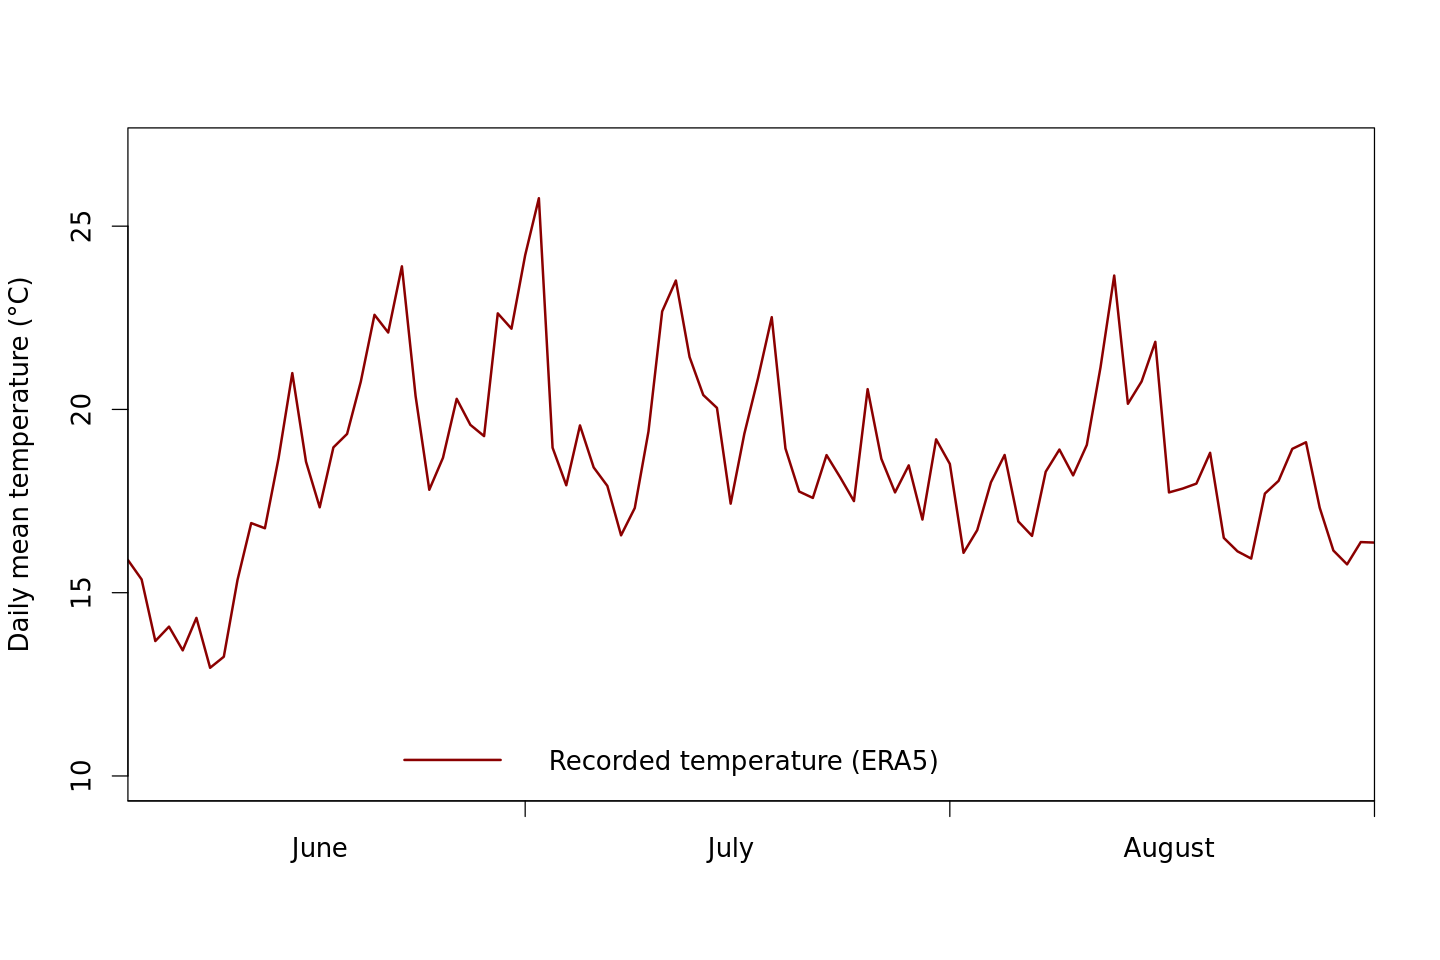

In [113]:
prep_window(h = 8, w = 12, cex = 1.3)
plot(t2m_f, type = "l", lwd = 2, col = "darkred", xlab = "", ylab = "Daily mean temperature (°C)", ylim = c(10,27), xaxt = "n", xaxs = "i")
# lines(cf_est, type = "l", lwd = 2, col = "darkblue")
axis(1, at = c(0,30,61,92), labels = rep("",4))
axis(1, at = c(15,45,77), labels = c("June", "July", "August"), tick = F)

# polygon(x = c(1:92, 92:1), y = c(cf_lower, rev(cf_upper)), density = NULL, border = NA, col = adjustcolor("blue", 0.3))

legend("bottomright", c("2025 recorded temperature (ERA5)"), lty = 1, lwd = 2, col = c("darkred", "darkblue"), bty = "n")

# Change in relative risk

In [65]:
suppressMessages({library(dplyr); library(dlnm)})


coef_si <- read.csv("../calculating-mortality/data/coef_mean.csv")        # using mean coeffs rather than MVN samples
t_mean <- read.csv("../calculating-mortality/data/tmean_distribution.csv")
cityage <- read.csv("../calculating-mortality/data/cityage.csv")
age.groups <- c("20-44", "45-64", "65-74", "75-84", "85+")

# factual & counterfactual temperatures
tmp_factuals <- read.csv("../calculating-mortality/data/city_coords_FACTUAL.csv")
tmp_counterfactuals <- read.csv("../calculating-mortality/data/city_coords_COUNTERFACTUAL.csv")


In [101]:
cit <- "UK001C"
ageg <- age.groups[3]

In [102]:
# retrieve population size & death rate per age group & city
cityage_f <- 
    cityage %>% 
    dplyr::filter((URAU_CODE %in% cit) & (agegroup %in% ageg)) %>% 
    dplyr::select(URAU_CODE, agegroup, agepop, death, deathrate)

# load quantiles of temperatures in selected city
temperature_grid <- t_mean[t_mean$URAU_CODE %in% cit,-1]

# extract the knots that were used in Pierre's study
per <- c(
    temperature_grid["X10.0."],
    temperature_grid["X75.0."],
    temperature_grid["X90.0."] 
)

# define the basis function that Pierre used to calculate the MMT
# constrained at knots ('per') but fitted to full range of temperatures ('temperature_grid')
basis <- onebasis(temperature_grid, 
                fun = "bs", 
                degree = 2, 
                knots = per %>% unlist())

# retrieve the coefficients of the city (just using coeff mean here)
coefs_city <- coef_si[coef_si$URAU_CODE %in% cit & 
                      coef_si$agegroup %in% ageg, 
                      paste0("b", 1:5)]

# calculate the MMT
temperature_grid = as.vector(temperature_grid) %>% unlist()
percentiles <- as.numeric(gsub("X|\\.$", "", colnames(temperature_grid)))

# if using fixed MMT, just get the value from Pierre's data
cityage %>% 
    dplyr::filter((URAU_CODE %in% cit) & (agegroup %in% ageg)) %>% 
    pull(mmt) -> mmt

# if not using fixed MMT, use the ith simulated set of beta coeffs to get the shape of the curve
# MMT is argmin of curve fitted between 1st and 99th percentiles
firstpred <- (as.matrix(coefs_city) %*% t(basis)) %>% as.vector()
mmt_sim <- temperature_grid[11:109][which.min(firstpred[11:109])]
mmt_offset <- min(firstpred[11:109])

In [103]:
# rescale predictive curve st MMT is at 0 (doesn't work to rescale basis functions later though - but handy for quickly plotting curves)
firstpred_rescaled <- scale(firstpred, center = mmt_offset, scale = F)

In [104]:
# rescale coeffs st MMT is at 0 (Gary's original approach - needed to scale the basis functions later)
bmmt <- onebasis(mmt_sim, 
                 fun = "bs", 
                 degree = 2, 
                 knots = per %>% unlist(), 
                 Boundary.knots = range(temperature_grid))

In [105]:
# ERF at all percentiles
basis_rescaled <- onebasis(
      temperature_grid, 
      fun = "bs", 
      degree = 2, 
      knots = per %>% unlist(), 
      Boundary.knots = range(temperature_grid)) |>
    scale(center = bmmt, scale = F)

pred_rescaled <- (as.matrix(coefs_city) %*% t(basis_rescaled)) %>% as.vector()

In [ ]:
# basis function using the counterfactuals 
# get counterfactual time series for given city
tmp_counterfactuals.pred <- 
      tmp_counterfactuals %>% 
        dplyr::filter(URAU_CODE %in% cit) %>% 
        dplyr::select(starts_with("X")) %>% 
        as.vector() %>% 
        unlist()

basis_c <- onebasis(
      tmp_counterfactuals.pred, 
      fun = "bs", 
      degree = 2, 
      knots = per %>% unlist(), 
      Boundary.knots = range(temperature_grid)) |>
scale(center = bmmt, scale = F)

# #~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~

# get factual time series for given city
tmp_factuals.pred <- 
    tmp_factuals %>% 
      dplyr::filter(URAU_CODE %in% cit) %>% 
      dplyr::select(starts_with("X")) %>% 
      as.vector() %>% 
      unlist()

# basis function using the factuals 
basis_f <- onebasis(
      tmp_factuals.pred, 
      fun = "bs", 
      degree = 2, 
      knots = per %>% unlist(), 
      Boundary.knots = range(c(temperature_grid, tmp_factuals.pred))) |>
    scale(center = bmmt, scale = F)

# reshape the betas
betas <- coefs_city %>% as.vector() %>% unlist()

log_rr_c <- basis_c %*% betas
log_rr_f <- basis_f %*% betas

In [ ]:
df <- data.frame("tas_f" = tmp_factuals.pred, "rr_f" = exp(log_rr_f), "tas_cf" = tmp_counterfactuals.pred, "rr_cf" = exp(log_rr_c))

In [136]:
ev1 <- df[which.max(tmp_factuals.pred),]
ev2 <- df[which.min(tmp_factuals.pred),]

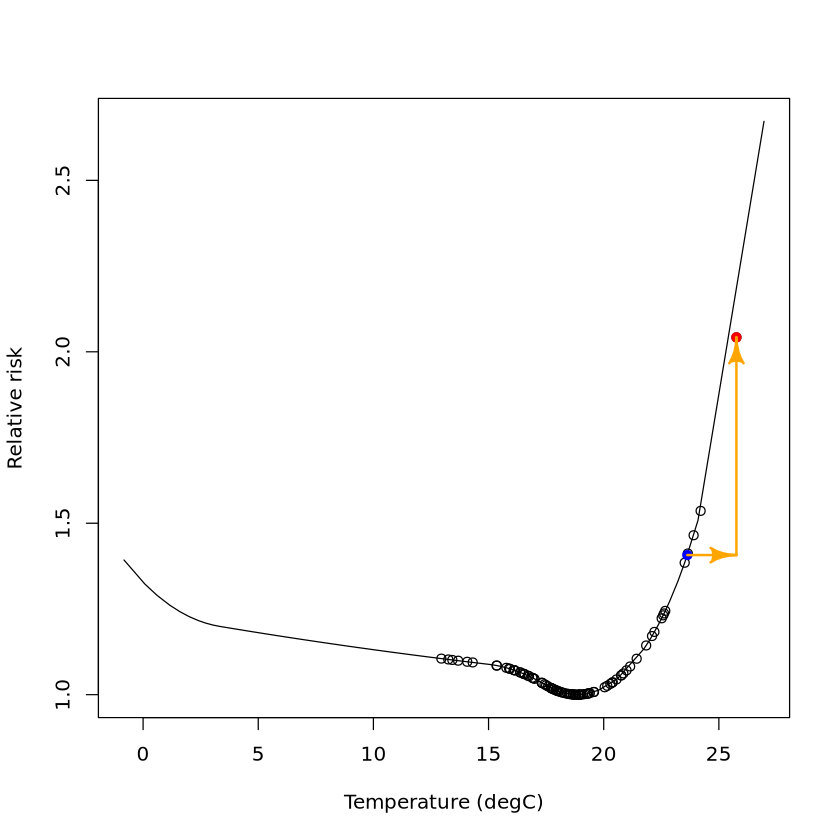

In [140]:
rr_cols <- c("blue3", "red4")[(log_rr_f > log_rr_c) + 1]

prep_window(c(1,1))

plot(temperature_grid[11:119], exp(pred_rescaled[11:119]), xlab = "Temperature (degC)", ylab = "Relative risk", type = "l")#, ylim = c(0,1))

points(tmp_factuals.pred, exp(log_rr_f)) # slight difference, need to check why

points(df[which.max(tmp_factuals.pred), c("tas_f", "rr_f")], col = "red", pch = 20, cex = 1.5)
points(df[which.max(tmp_factuals.pred), c("tas_cf", "rr_cf")], col = "blue", pch = 20, cex = 1.5)

Arrows(ev1$tas_cf,ev1$rr_cf,ev1$tas_f,ev1$rr_cf, col = "orange", lw = 2, arr.adj = 1, arr.type = "curved")
Arrows(ev1$tas_f,ev1$rr_cf,ev1$tas_f,ev1$rr_f, col = "orange", lw = 2, arr.adj = 1, arr.type = "curved")

# Arrows(ev2$tas_cf,ev2$rr_cf,ev2$tas_f,ev2$rr_cf, col = "cornflowerblue", lw = 2, arr.adj = 1, arr.type = "curved")
# Arrows(ev2$tas_f,ev2$rr_cf,ev2$tas_f,ev2$rr_f, col = "cornflowerblue", lw = 2, arr.adj = 1, arr.type = "curved")

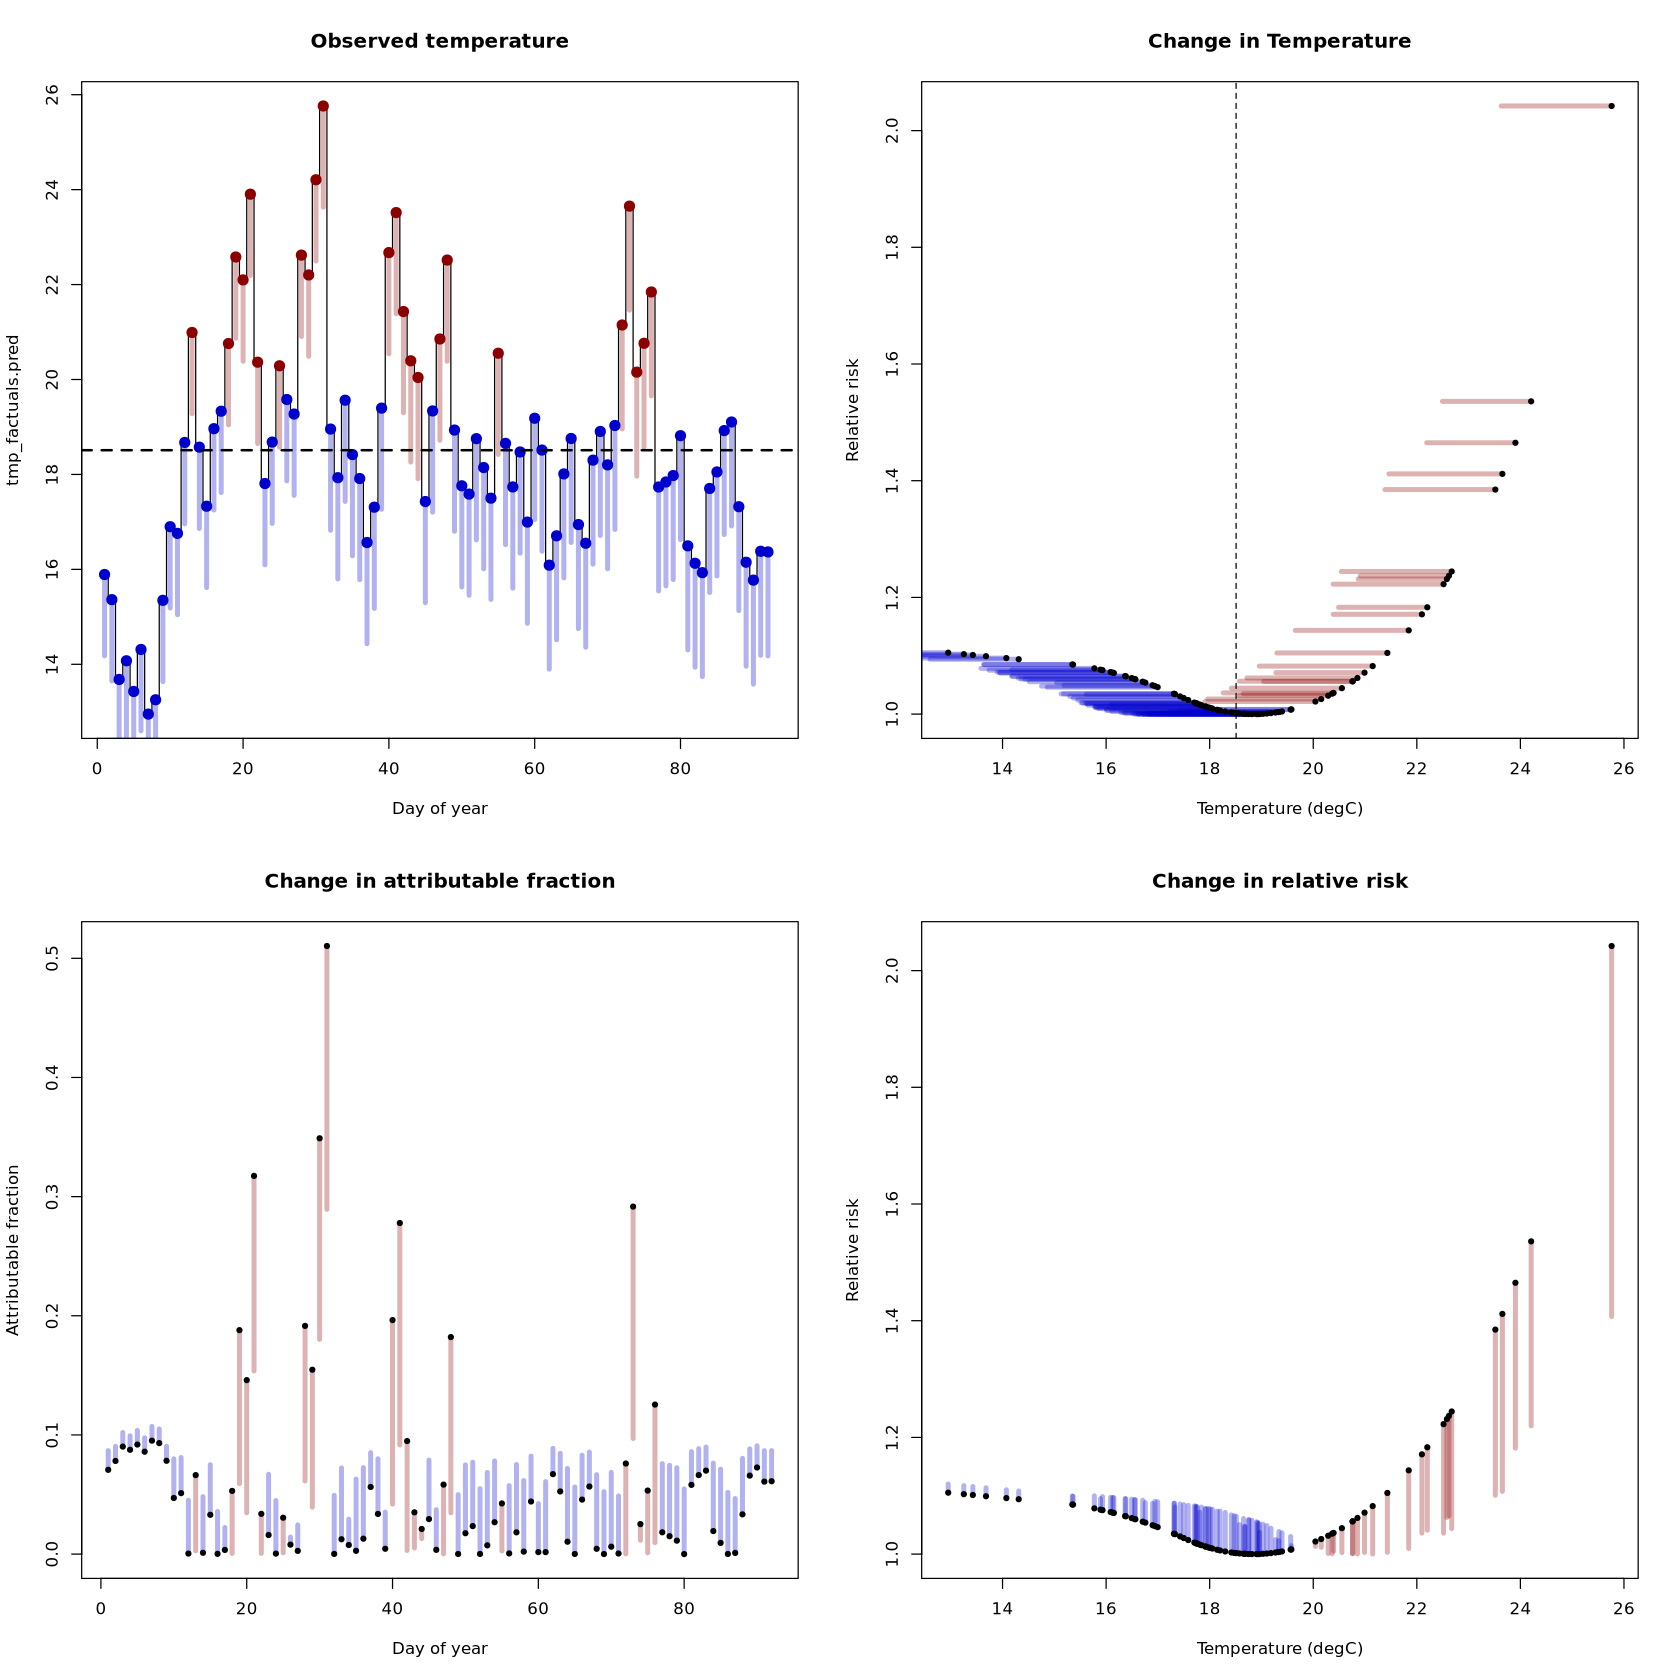

In [69]:
prep_window(c(2,2))

rr_cols <- c("blue3", "red4")[(log_rr_f > log_rr_c) + 1]

plot((1:92)+0.5, tmp_factuals.pred, type = "S", main = "Observed temperature", xlab = "Day of year")
segments(x0 = (1:92), y0 = tmp_factuals.pred, y1 = tmp_counterfactuals.pred, col = adjustcolor(rr_cols, 0.3), lwd = 4)
points((1:92), tmp_factuals.pred, pch = 20, cex = 2, col = rr_cols)
abline(h = mmt, lty = 2, lwd = 2)

matplot(tmp_factuals.pred, cbind(exp(log_rr_c), exp(log_rr_f)), type = "n", main = "Change in Temperature", xlab = "Temperature (degC)", ylab = "Relative risk")
segments(x0 = tmp_counterfactuals.pred, x1 = tmp_factuals.pred, y0 = exp(log_rr_f), col = adjustcolor(rr_cols, 0.3), lwd = 4)
points(tmp_factuals.pred, exp(log_rr_f), pch = 20, col = "black")
abline(v = mmt, lty = 2)


# matplot(1:92, cbind(afday_c, afday_f), type = "n", main = "Change in attributable fraction", xlab = "Day of year", ylab = "Attributable fraction")
# segments(x0 = 1:92, y0 = afday_c, y1 = afday_f, col = adjustcolor(rr_cols, 0.3), lwd = 4)
# points(1:92, afday_f, pch = 20, col = "black")

# # Overlay with temperatures
# par(new = TRUE)
# plot((1:92), tmp_factuals.pred, pch = 1, axes = FALSE, bty = "n", xlab = "", ylab = "")
# axis(side=4, at = pretty(range(tmp_factuals.pred)))

# matplot(tmp_factuals.pred, cbind(afday_c, afday_f), type = "n", main = "Change in attributable fraction", xlab = "Temperature (degC)")
# segments(x0 = tmp_factuals.pred, y0 = afday_c, y1 = afday_f, col = rr_cols, lwd = 4)
# points(tmp_factuals.pred, afday_f, pch = 20, col = "black")


matplot(tmp_factuals.pred, cbind(exp(log_rr_c), exp(log_rr_f)), type = "n", main = "Change in relative risk", xlab = "Temperature (degC)", ylab = "Relative risk")
segments(x0 = tmp_factuals.pred, y0 = exp(log_rr_c), y1 = exp(log_rr_f), col = adjustcolor(rr_cols, 0.3), lwd = 4)
points(tmp_factuals.pred, exp(log_rr_f), pch = 20, col = "black")